In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [27]:
# Loading the CSV file for Great Lakes TP and TN
df = pd.read_csv("All_Lakes_GLIP_1976_2023.csv")

In [28]:
# Filter only for TP, TN, and Chl-a
target_params = {
    "Phosphorus; total": "TP (mg/L)",
    "Chlorophyll - a; total": "Chl-a (µg/L)"
}
df = df[df["PARAMETER"].isin(target_params.keys())]
df["PARAMETER"] = df["PARAMETER"].replace(target_params)

In [29]:
# Convert date and extract year
df["DATE"] = pd.to_datetime(df["DATE_YYYYMMDD"], errors="coerce")
df["YEAR"] = df["DATE"].dt.year

In [30]:
# Drop rows without year
df = df.dropna(subset=["YEAR"])

In [31]:
# Group and average by year, lake, and parameter
grouped = (
    df.groupby(["YEAR", "LAKE", "PARAMETER"])["RESULT_VALUE"]
    .mean()
    .reset_index()
)

In [32]:
# Set seaborn style
sns.set(style="whitegrid")

In [33]:
# Function to plot time series
def plot_parameter(param):
    plt.figure(figsize=(12, 6))
    data = grouped[grouped["PARAMETER"] == param]
    sns.lineplot(
        data=data,
        x="YEAR",
        y="RESULT_VALUE",
        hue="LAKE",
        marker="o",
        markersize=6,
        linewidth=2,
        palette="colorblind"
    )
    plt.title(f"{param} Over Time (1976–2023)", fontsize=14)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel(param, fontsize=12)
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.legend(title="Lake", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
    plt.tight_layout()
    plt.show()


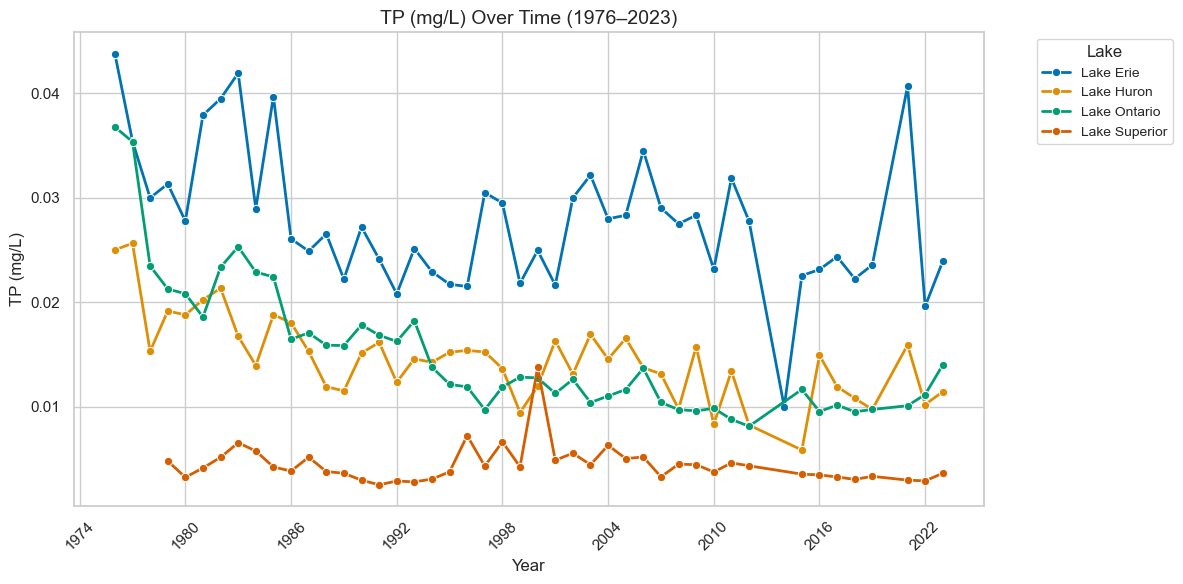

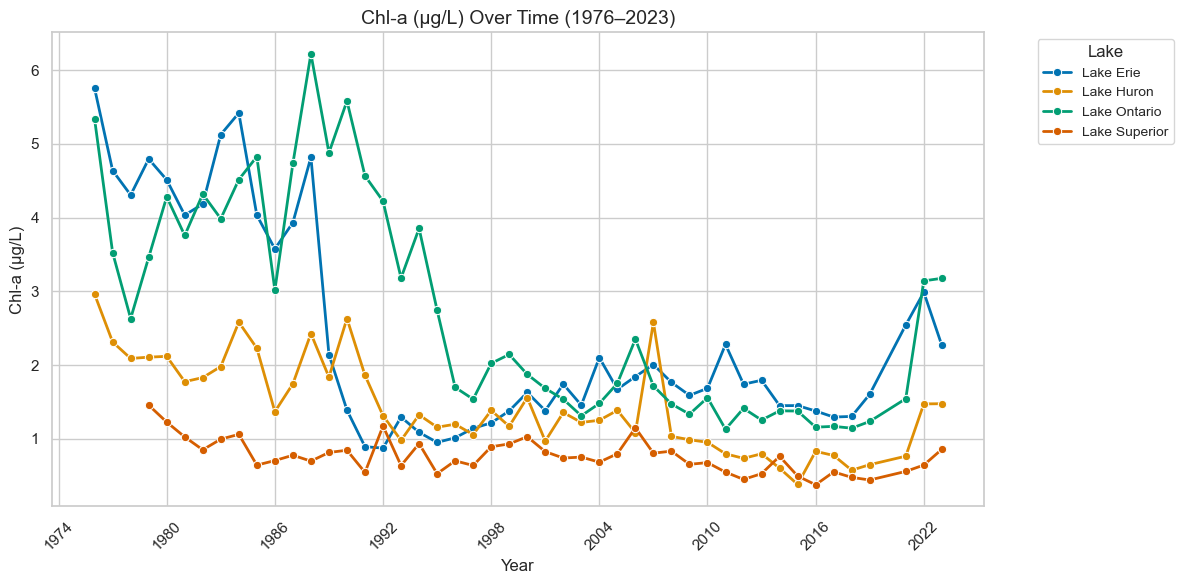

In [34]:
#  plots for Total Phosphorus (TP) and Nitrogen (TN) in Great Lakes at Ontario
plot_parameter("TP (mg/L)")
plot_parameter("Chl-a (µg/L)")
